<a href="https://colab.research.google.com/github/IvanIri/Procesamiento-del-Habla/blob/main/Irigoyen_Ivan_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Iván Irigoyen.]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
import requests
from bs4 import BeautifulSoup

In [2]:
url = "https://www.casarosada.gob.ar/la-casa-rosada/historia"

# creo un agente para me permita extraer la información
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
}

respuesta = requests.get(url, headers=headers)
respuesta.raise_for_status()

print("Status:", respuesta.status_code)

Status: 200


In [3]:
# Parseamos el contenido HTML
soup = BeautifulSoup(respuesta.text, "html.parser")

# Extraemos el texto de la página
texto = soup.get_text(separator=" ", strip=True)

# Mostramos solo los primeros 1000 caracteres
print(texto[:1000])

HISTORIA Toggle navigation Casa Rosada Presidencia de la Nación Autoridades Presidente Javier Milei Vicepresidente Victoria Villarruel Jefe de Gabinete de Ministros Diego César Santilli Secretaria General Karina Milei Información Información Trámites y servicios Mapa del Estado Actividad oficial Conferencias Discursos Fotos Paseo de la República Archivo Transparencia Nuestro País Acerca de Argentina Organización Símbolos Nacionales Constitución Nacional Presidentes La Casa Historia Puntos de Interés Visitas Guiadas Museo Bustos Presidenciales EN Presidencia Javier Milei Contacto Suscribite Historia de la Casa Rosada Origen El solar en el que está emplazada la Casa Rosada fue, durante toda la historia de Buenos Aires, la sede de las distintas y sucesivas autoridades políticas que gobernaron el país. A poco de fundar la Ciudad en 1580, Don Juan de Garay mandó cavar una zanja y terraplenes formados con las mismas tierras extraídas de ella, encerrando dentro el origen de lo que más adelant

Cree un agente que me permita ingresar a la pagina y realizar el webscrapping.

luego con "requests" lo guardamos por la variable "respuesta.

luego convierto el contenido en html para poder leerlo, le indico cuales el separador para extraer el texto y por ultimo le indico solo las primeras 1000 palabras ya que es un texto largo.

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [4]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
# Separamos el texto en palabras
palabras = texto.lower().split()

# Buscamos las stop words presentes en el texto
stopwords_texto = [palabra for palabra in palabras if palabra in stop_words]

print(stopwords_texto[:100])

['de', 'la', 'de', 'de', 'y', 'del', 'estado', 'de', 'la', 'nuestro', 'de', 'la', 'de', 'en', 'de', 'la', 'el', 'en', 'el', 'que', 'está', 'la', 'durante', 'la', 'de', 'la', 'de', 'las', 'y', 'que', 'el', 'a', 'poco', 'de', 'la', 'en', 'de', 'una', 'y', 'con', 'las', 'de', 'el', 'de', 'lo', 'que', 'más', 'se', 'de', 'de', 'o', 'de', 'en', 'el', 'de', 'una', 'de', 'de', 'con', 'y', 'que', 'se', 'en', 'la', 'por', 'las', 'e', 'y', 'la', 'sobre', 'las', 'que', 'al', 'a', 'del', 'se', 'un', 'de', 'y', 'hasta', 'su', 'un', 'y', 'ya', 'en', 'el', 'de', 'la', 'la', 'que', 'había', 'de', 'y', 'con', 'muy', 'a', 'las', 'de', 'los', 'las']


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [6]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pasamos todo el texto a minúsculas
texto_limpio = texto.lower()

# Eliminamos números, signos de puntuación y caracteres extraños
texto_limpio = re.sub(r'[^a-záéíóúüñ\s]', '', texto_limpio)

# Separamos el texto en palabras
palabras = texto_limpio.split()

# Eliminamos las stop words
palabras_limpias = [
    palabra for palabra in palabras
    if palabra not in stop_words
]

# Volvemos a unir las palabras en un texto
texto_final = " ".join(palabras_limpias)

# Mostramos una parte del resultado
print(texto_final[:1000])

historia toggle navigation casa rosada presidencia nación autoridades presidente javier milei vicepresidente victoria villarruel jefe gabinete ministros diego césar santilli secretaria general karina milei información información trámites servicios mapa actividad oficial conferencias discursos fotos paseo república archivo transparencia país acerca argentina organización símbolos nacionales constitución nacional presidentes casa historia puntos interés visitas guiadas museo bustos presidenciales presidencia javier milei contacto suscribite historia casa rosada origen solar emplazada casa rosada toda historia buenos aires sede distintas sucesivas autoridades políticas gobernaron país fundar ciudad don juan garay mandó cavar zanja terraplenes formados mismas tierras extraídas encerrando dentro origen adelante llamó real fortaleza san juan baltasar austria castillo san miguel posteriormente gobernador fernando zárate mandó levantar amurallada construcción metros lado foso puente levadizo 

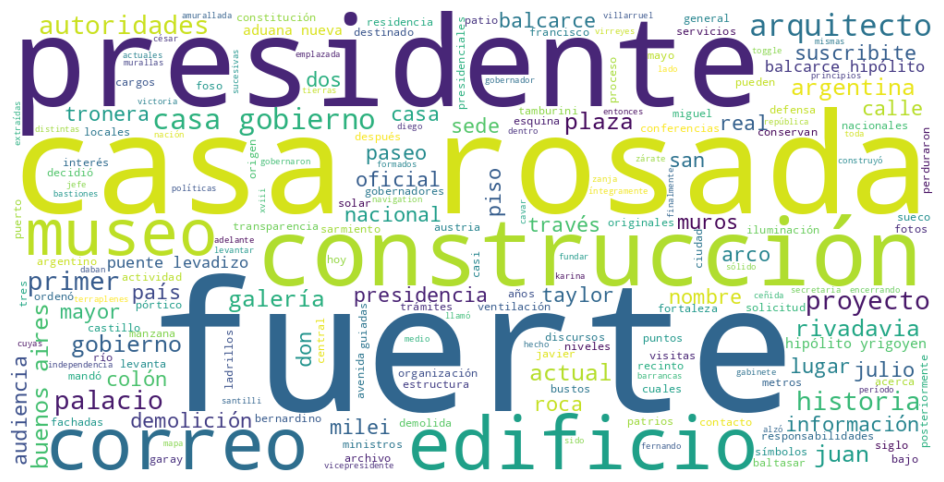

In [7]:
# Crear nube de palabras
nube = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(texto_final)

# Mostrar nube
plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [8]:
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

# Dividimos el texto original en oraciones
oraciones = sent_tokenize(texto, language='spanish')

print("Cantidad de oraciones:", len(oraciones))

# Mostramos las primeras 5
for oracion in oraciones[:5]:
    print(oracion)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Cantidad de oraciones: 39
HISTORIA Toggle navigation Casa Rosada Presidencia de la Nación Autoridades Presidente Javier Milei Vicepresidente Victoria Villarruel Jefe de Gabinete de Ministros Diego César Santilli Secretaria General Karina Milei Información Información Trámites y servicios Mapa del Estado Actividad oficial Conferencias Discursos Fotos Paseo de la República Archivo Transparencia Nuestro País Acerca de Argentina Organización Símbolos Nacionales Constitución Nacional Presidentes La Casa Historia Puntos de Interés Visitas Guiadas Museo Bustos Presidenciales EN Presidencia Javier Milei Contacto Suscribite Historia de la Casa Rosada Origen El solar en el que está emplazada la Casa Rosada fue, durante toda la historia de Buenos Aires, la sede de las distintas y sucesivas autoridades políticas que gobernaron el país.
A poco de fundar la Ciudad en 1580, Don Juan de Garay mandó cavar una zanja y terraplenes formados con las mismas tierras extraídas de ella, encerrando dentro el or

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [9]:
oraciones_limpias = []

for oracion in oraciones:

    # Pasamos a minúsculas
    oracion = oracion.lower()

    # Eliminamos números y caracteres extraños
    oracion = re.sub(r'[^a-záéíóúüñ\s]', '', oracion)

    # Separamos en palabras
    palabras = oracion.split()

    # Eliminamos stop words
    palabras = [
        palabra for palabra in palabras
        if palabra not in stop_words
    ]

    # Volvemos a unir las palabras
    oracion_limpia = " ".join(palabras)

    # Evitamos agregar oraciones vacías
    if oracion_limpia:
        oraciones_limpias.append(oracion_limpia)

# Mostramos algunas
for oracion in oraciones_limpias[:5]:
    print(oracion)

historia toggle navigation casa rosada presidencia nación autoridades presidente javier milei vicepresidente victoria villarruel jefe gabinete ministros diego césar santilli secretaria general karina milei información información trámites servicios mapa actividad oficial conferencias discursos fotos paseo república archivo transparencia país acerca argentina organización símbolos nacionales constitución nacional presidentes casa historia puntos interés visitas guiadas museo bustos presidenciales presidencia javier milei contacto suscribite historia casa rosada origen solar emplazada casa rosada toda historia buenos aires sede distintas sucesivas autoridades políticas gobernaron país
fundar ciudad don juan garay mandó cavar zanja terraplenes formados mismas tierras extraídas encerrando dentro origen adelante llamó real fortaleza san juan baltasar austria castillo san miguel
posteriormente gobernador fernando zárate mandó levantar amurallada construcción metros lado foso puente levadizo 

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Crear el vectorizador
vectorizer = CountVectorizer()

# Crear la matriz documento-vocabulario
matriz = vectorizer.fit_transform(oraciones_limpias)

# Obtener el vocabulario
vocabulario = vectorizer.get_feature_names_out()

print("Dimensiones de la matriz:", matriz.shape)

Dimensiones de la matriz: (39, 491)


In [15]:
# Convertir la matriz en DataFrame
df_matriz = pd.DataFrame(
    matriz.toarray(),
    columns=vocabulario
)

df_matriz.head()

,abandonada,aberg,abovedados,acceden,acerca,acero,acompañarte,actividad,actual,actuales,...,visitarse,visitas,volvió,xviii,yrigoyen,zanja,zárate,íntegramente,últimas,últimos
0,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [16]:
longitud_vocabulario = len(vocabulario)

print("Longitud del vocabulario:", longitud_vocabulario)

Longitud del vocabulario: 491



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear vectorizador TF-IDF
tfidf = TfidfVectorizer()

# Aplicar TF-IDF a las oraciones
matriz_tfidf = tfidf.fit_transform(oraciones_limpias)

# Obtener vocabulario
vocabulario_tfidf = tfidf.get_feature_names_out()

# Convertir a DataFrame para visualizar
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocabulario_tfidf
)

df_tfidf.head()

,abandonada,aberg,abovedados,acceden,acerca,acero,acompañarte,actividad,actual,actuales,...,visitarse,visitas,volvió,xviii,yrigoyen,zanja,zárate,íntegramente,últimas,últimos
0,0.0,0.0,0.0,0.0,0.092538,0.0,0.0,0.092538,0.0,0.000000,...,0.0,0.092538,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.193912,0.000000,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.203915,...,0.0,0.000000,0.0,0.000000,0.168541,0.000000,0.203915,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.232735,0.000000,0.000000,0.000000,0.232735,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [21]:
# Elegimos una oración
numero_oracion = 30

# Obtenemos los valores TF-IDF
valores = df_tfidf.iloc[numero_oracion]

# Nos quedamos con los 10 valores más altos
top_palabras = valores.sort_values(ascending=False).head(10)

print("Oración original:")
print(oraciones[numero_oracion])

print("\nPalabras con mayor TF-IDF:")
print(top_palabras)

Oración original:
El Palacio El conjunto edilicio se desarrolla en tres niveles sobre la calle Balcarce y en cuatro niveles más un subsuelo/galerías del Museo de la Casa de Gobierno, sobre la avenida Paseo Colón, ocupando una superficie de casi una manzana.

Palabras con mayor TF-IDF:
niveles             0.461222
desarrolla          0.230611
edilicio            0.230611
conjunto            0.230611
ocupando            0.230611
subsuelogalerías    0.230611
calle               0.230611
cuatro              0.230611
superficie          0.230611
tres                0.207210
Name: 30, dtype: float64


In [18]:
print("Dimensiones TF-IDF:", matriz_tfidf.shape)

Dimensiones TF-IDF: (39, 491)


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

El trabajo de webscrapping fue hecho extrayendo un texto historico de La Casa Rosada extraido de la propia web de La Casa Rosada.

El texto cuenta con unas 39 oraciones y 491 palabras. Donde las mas comunes son "fuerte", "Casa Rosada", "Presidentes", "construcción" y "museo" como se identifican claramente en el wordcloud. Lo cual tiene sentido dado que la Casa Rosada funciono originalmente como un fuerte para proteger la costa y el resto tienen que ver con su uso actual, que es el palacio de gobierno, además de tener un museo dentro.  


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

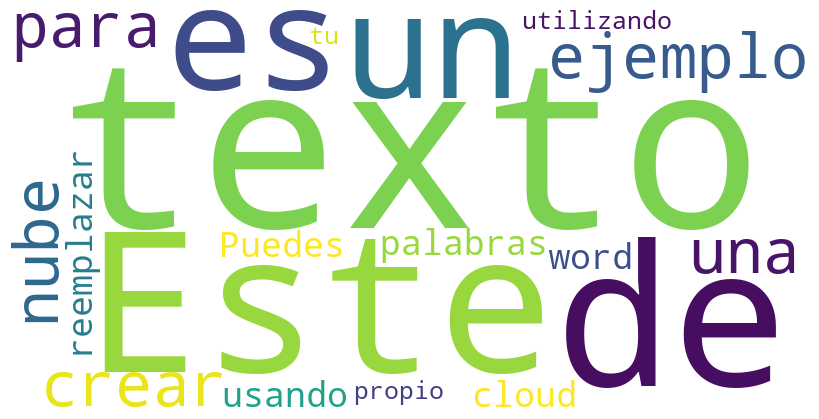

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



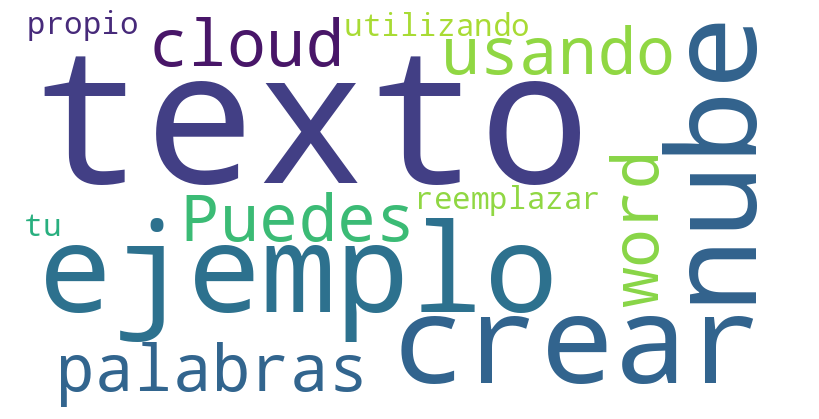

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
